## Contexte

Les institutions financières doivent constamment évaluer le risque associé à l’octroi de crédits afin de minimiser les pertes dues aux défauts de paiement. L’objectif de ce projet est de développer un modèle de prédiction durisque de défaut de crédit en utilisant des données réelles de prêt issues de Kaggle. En alliant l’économétrie financière et les techniques de machine learning, ce projet nous permettra de construire un système de scoring de crédit robuste tout en appliquant les meilleures pratiques de traitement des données, d’analyse statistiqueet de modélisation.

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split # Pour séparer le jeu de donnée en jeu de donnée de test et d'entrainement
from sklearn.utils import resample
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split # Pour séparer le jeu de donnée en jeu de donnée de test et d'entrainement
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.model_selection import RandomizedSearchCV



# Exploration et préparation des données

## Chargement du jeu de donnée crédit scoring

In [2]:
folder_path = r'C:\Users\NDEYE SEYNABOU TALL\Pratique_Mr_SY\Projet_credit_scoring'
for filename in os.listdir(folder_path):
    print (filename)

.ipynb_checkpoints
application.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
HomeCredit_columns_description.csv
installments_payments.csv
POS_CASH_balance.csv
previous_application.csv
sample_submission.csv


In [3]:
file_path = os.path.join(folder_path, 'application_test.csv')
credit_test = pd.read_csv(file_path)
credit_test.shape

(48744, 121)

In [4]:
print(credit_test.head())

   SK_ID_CURR NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0      100001         Cash loans           F            N               Y   
1      100005         Cash loans           M            N               Y   
2      100013         Cash loans           M            Y               Y   
3      100028         Cash loans           F            N               Y   
4      100038         Cash loans           M            Y               N   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          135000.0    568800.0      20560.5         450000.0   
1             0           99000.0    222768.0      17370.0         180000.0   
2             0          202500.0    663264.0      69777.0         630000.0   
3             2          315000.0   1575000.0      49018.5        1575000.0   
4             1          180000.0    625500.0      32067.0         625500.0   

   ... FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG

In [5]:
file_path = os.path.join(folder_path, 'application_train.csv')
credit_train = pd.read_csv(file_path)
credit_train.shape


(307511, 122)

In [6]:
print(credit_train.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 0             

In [8]:
missing_values = credit_train.isnull().sum()
print("Valeurs manquantes :\n", missing_values[missing_values > 0])

Valeurs manquantes :
 AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64


# Identifions la variable cible

In [9]:
credit_train.columns
if 'TARGET' in credit_train.columns:  # Remplacez 'TARGET' par le nom exact de la colonne
     print(credit_train['TARGET'].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [10]:
credit_train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

# Les caractéristiques explicatives 

In [11]:
# Séparer les colonnes explicatives (sans SK_ID_CURR et TARGET)
features = credit_train.drop(columns=['TARGET', 'SK_ID_CURR'])  
# Analyser les variables numériques
numeric_features = features.select_dtypes(include=['float64', 'int64'])
print("Variables numériques :\n", numeric_features.columns)

# Analyser les variables catégoriques
categorical_features = features.select_dtypes(include=['object'])
print("Variables catégoriques :\n", categorical_features.columns)

# Corrélation avec la cible
correlation = numeric_features.corrwith(credit_train['TARGET'])
print("Corrélations avec la cible :\n", correlation.sort_values(ascending=False))

Variables numériques :
 Index(['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=104)
Variables catégoriques :
 Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')
Corrélations ave

# Analyse exploreatoire des données

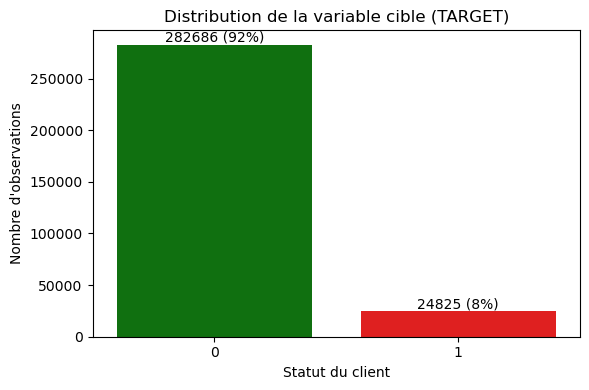

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

palette = {0: "green", 1: "red"}

sns.countplot(
    x='TARGET',
    data=credit_train,
    hue='TARGET',
    palette=palette,
    legend=False,
    ax=ax
)

# Calcul des pourcentages
total = len(credit_train)

for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(
        f'{count} ({percent:.0f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title("Distribution de la variable cible (TARGET)")
ax.set_xlabel("Statut du client")
ax.set_ylabel("Nombre d'observations")
# ax.set_xticklabels(["Non défaut (0)", "Défaut (1)"])

# Ajustement + sauvegarde AVANT show
plt.tight_layout()
plt.savefig(
    "distribution_target.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Relation entre les variables  et la variable cible

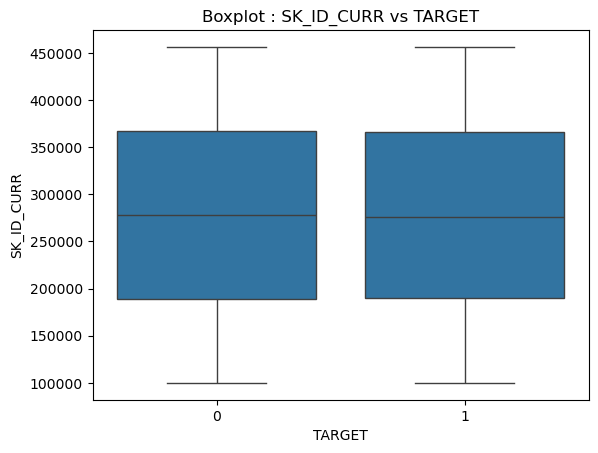

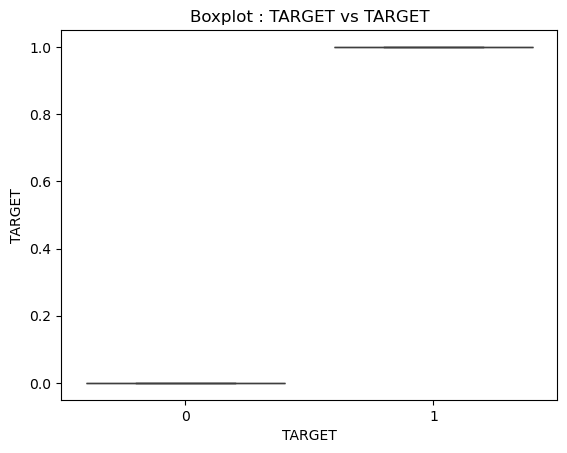

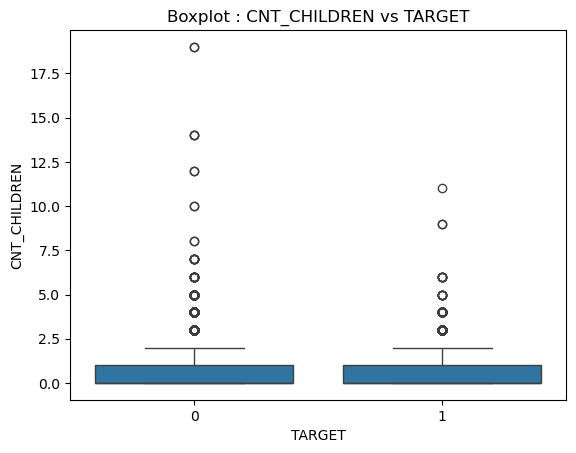

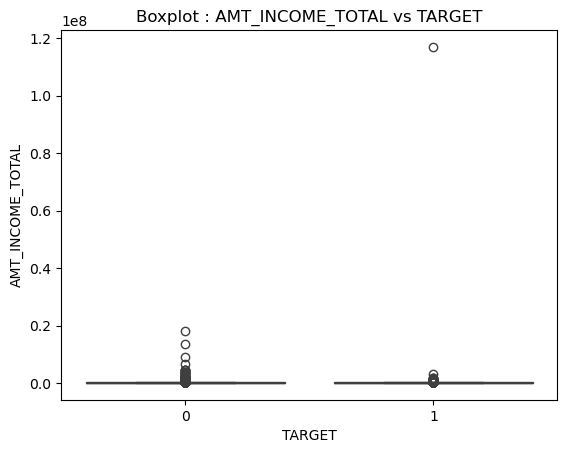

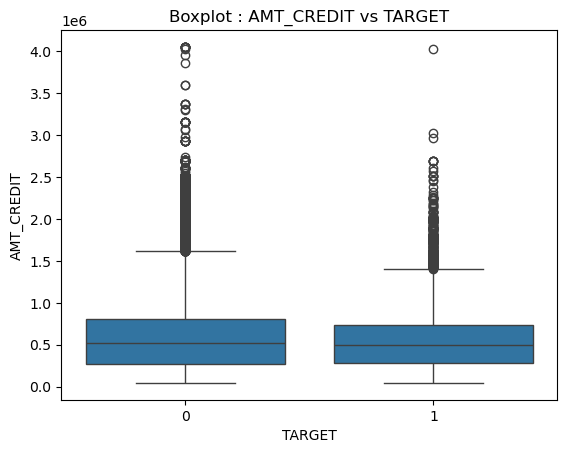

In [13]:
# Exemple avec les 5 premières colonnes numériques
numeric_columns = credit_train.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_columns[:5]:
    if 'TARGET' in credit_train.columns:
        sns.boxplot(x=credit_train['TARGET'], y=credit_train[col])
        plt.title(f"Boxplot : {col} vs TARGET")
        plt.show()

### Calculez et visualisez une matrice de corrélation pour identifier les relations entre les variables et la cible.

Corrélation avec la cible :
 TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
                                 ...   
FLOORSMAX_AVG                 -0.044003
DAYS_EMPLOYED                 -0.044932
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
Length: 106, dtype: float64


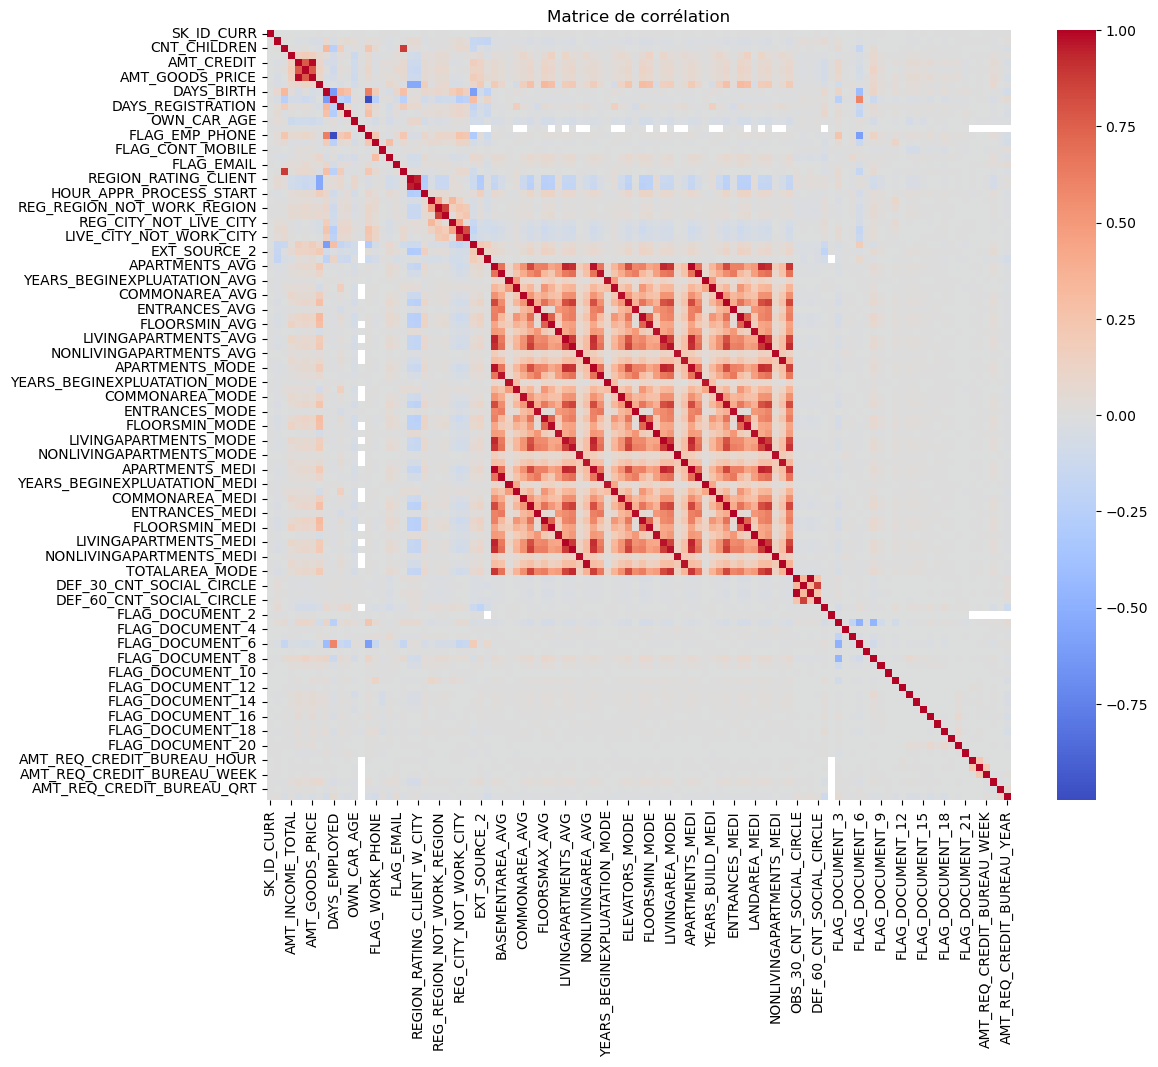

In [14]:
# Corrélation avec la cible
if 'TARGET' in credit_train.columns:
    correlation = credit_train[numeric_columns].corrwith(credit_train['TARGET'])
    print("Corrélation avec la cible :\n", correlation.sort_values(ascending=False))

# Matrice de corrélation
correlation_matrix = credit_train[numeric_columns].corr()

# Afficher la matrice de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title("Matrice de corrélation")
plt.show()

## Traitement des valeurs manquantes et des valeurs extrêmes

In [15]:

# Étape 1 : Identifier les valeurs manquantes
missing_values = credit_train.isnull().sum()

  # Compte les valeurs manquantes par colonne
missing_percentage = (missing_values / len( credit_train)) * 100  # Calculer le pourcentage


# Afficher les colonnes avec des valeurs manquantes
missing_summary = pd.DataFrame({'Valeurs Manquantes': missing_values, 'Pourcentage': missing_percentage})

missing_summary = missing_summary[missing_summary['Valeurs Manquantes'] > 0].sort_values(by='Pourcentage', ascending=False)

print("Résumé des valeurs manquantes :")
print(missing_summary)

# Étape 2 : Traiter les valeurs manquantes
#  Imputation des valeurs manquantes
# Pour les colonnes numériques : remplacement par la médiane
numerical_cols =  credit_train.select_dtypes(include=['float64', 'int64']).columns


credit_train[numerical_cols] =  credit_train[numerical_cols].fillna( credit_train[numerical_cols].median())

# Pour les colonnes catégoriques : remplacement par le mode (valeur la plus fréquente)
categorical_cols =  credit_train.select_dtypes(include=['object']).columns


credit_train[categorical_cols] =  credit_train[categorical_cols].fillna( credit_train[categorical_cols].mode().iloc[0])

print("Les valeurs manquantes ont été traitées.")

Résumé des valeurs manquantes :
                          Valeurs Manquantes  Pourcentage
COMMONAREA_MEDI                       214865    69.872297
COMMONAREA_MODE                       214865    69.872297
COMMONAREA_AVG                        214865    69.872297
NONLIVINGAPARTMENTS_MODE              213514    69.432963
NONLIVINGAPARTMENTS_MEDI              213514    69.432963
...                                      ...          ...
EXT_SOURCE_2                             660     0.214626
AMT_GOODS_PRICE                          278     0.090403
AMT_ANNUITY                               12     0.003902
CNT_FAM_MEMBERS                            2     0.000650
DAYS_LAST_PHONE_CHANGE                     1     0.000325

[67 rows x 2 columns]
Les valeurs manquantes ont été traitées.


In [15]:
# Vérifier les classes avant SMOTE
print(credit_train['TARGET'].unique())  # Affiche les classes présentes

# Filtrer les classes existantes
data = credit_train[credit_train['TARGET'].isin([0, 1])]  # Assurez-vous que seules les classes valides sont incluses

[1 0]


# Identifions les valeurs aberrantes 

## Visualisons les valeurs aberrantes

In [16]:
# Identification des outliers pour chaque colonne numérique
numeric_columns = credit_train.select_dtypes(include=[ 'float','int64']).columns

for col in numeric_columns:
    Q1 = credit_train[col].quantile(0.25)
    Q3 = credit_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = credit_train[(credit_train[col] < (Q1 - 1.5 * IQR)) | (credit_train[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers")

SK_ID_CURR: 0 outliers
TARGET: 24825 outliers
CNT_CHILDREN: 4272 outliers
AMT_INCOME_TOTAL: 14035 outliers
AMT_CREDIT: 6562 outliers
AMT_ANNUITY: 7504 outliers
AMT_GOODS_PRICE: 14728 outliers
REGION_POPULATION_RELATIVE: 8412 outliers
DAYS_BIRTH: 0 outliers
DAYS_EMPLOYED: 72217 outliers
DAYS_REGISTRATION: 659 outliers
DAYS_ID_PUBLISH: 0 outliers
OWN_CAR_AGE: 99562 outliers
FLAG_MOBIL: 1 outliers
FLAG_EMP_PHONE: 55386 outliers
FLAG_WORK_PHONE: 61308 outliers
FLAG_CONT_MOBILE: 574 outliers
FLAG_PHONE: 0 outliers
FLAG_EMAIL: 17442 outliers
CNT_FAM_MEMBERS: 4007 outliers
REGION_RATING_CLIENT: 80527 outliers
REGION_RATING_CLIENT_W_CITY: 78027 outliers
HOUR_APPR_PROCESS_START: 2257 outliers
REG_REGION_NOT_LIVE_REGION: 4657 outliers
REG_REGION_NOT_WORK_REGION: 15612 outliers
LIVE_REGION_NOT_WORK_REGION: 12503 outliers
REG_CITY_NOT_LIVE_CITY: 24039 outliers
REG_CITY_NOT_WORK_CITY: 70867 outliers
LIVE_CITY_NOT_WORK_CITY: 55215 outliers
EXT_SOURCE_1: 134131 outliers
EXT_SOURCE_2: 0 outliers
EXT_S

### Visualisation des valeurs aberrantes 

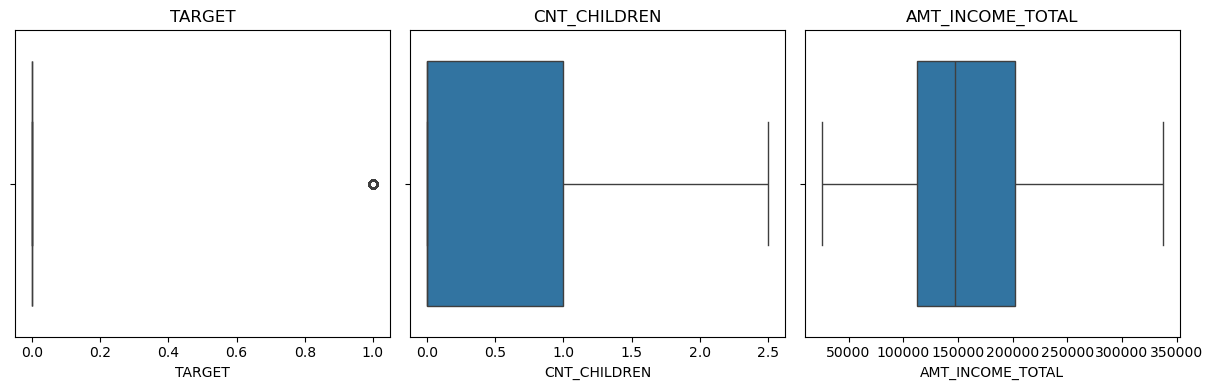

In [25]:
numeric_cols = ['TARGET','CNT_CHILDREN', 'AMT_INCOME_TOTAL']

plt.figure(figsize=(12, 4))  # largeur plus grande pour 3 plots

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)  # 1 ligne, 3 colonnes, position i
    sns.boxplot(x=credit_train[col])
    plt.title(f"{col}")

plt.tight_layout()

# --- Sauvegarde de la figure ---
plt.savefig("Boxplots_Variables_Numeriques.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
# Fonction pour détecter les valeurs aberrantes dans une colonne
def detect_outliers(column):
    Q1 = column.quantile(0.25)  # 1er quartile
    Q3 = column.quantile(0.75)  # 3e quartile
    IQR = Q3 - Q1               # Écart interquartile
    lower_bound = Q1 - 1.5 * IQR  # Limite inférieure
    upper_bound = Q3 + 1.5 * IQR  # Limite supérieure
    return (column < lower_bound) | (column > upper_bound)

# Sélection des colonnes numériques
numerical_cols = credit_train.select_dtypes(include=['float64', 'int64']).columns
if 'TARGET' in numerical_cols:
    numerical_cols = numerical_cols.drop('TARGET')

# Création du DataFrame des masques d'outliers
outlier_masks = {col: detect_outliers(credit_train[col]) for col in numerical_cols}

# Conversion du dictionnaire en DataFrame
outliers = pd.DataFrame(outlier_masks)

# Résumé des pourcentages d'outliers par colonne
outlier_summary = outliers.sum() / len(credit_train) * 100
print("Pourcentage de valeurs aberrantes par colonne :")
print(outlier_summary[outlier_summary > 0].sort_values(ascending=False))

# Visualisation des boxplots pour les colonnes avec des valeurs aberrantes
cols_with_outliers = outlier_summary[outlier_summary > 0].index

for col in cols_with_outliers:
    plt.figure(figsize=(8, 4))
    plt.boxplot(credit_train[col].dropna(), vert=False)
    plt.title(f"Boxplot pour {col}")
    plt.show()

# Traitement des valeurs aberrantes : Remplacement par les limites de l'IQR
for col in cols_with_outliers:
    Q1 = credit_train[col].quantile(0.25)
    Q3 = credit_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remplacement des outliers
    credit_train[col] = np.where(credit_train[col] < lower_bound, lower_bound, credit_train[col])
    credit_train[col] = np.where(credit_train[col] > upper_bound, upper_bound, credit_train[col])

print("Traitement des valeurs aberrantes terminé.")

Pourcentage de valeurs aberrantes par colonne :
Series([], dtype: float64)
Traitement des valeurs aberrantes terminé.


In [23]:
# Vérifier les classes 
print(credit_train['TARGET'].unique())  # Affiche les classes présentes

# Filtrer les classes existantes
credit_train = credit_train[credit_train['TARGET'].isin([0, 1])]  # Assurez-vous que seules les classes valides sont incluses

[1 0]


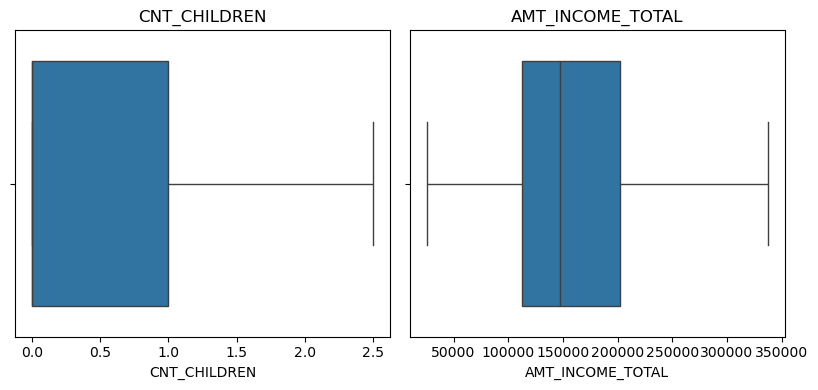

In [32]:
numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL']

plt.figure(figsize=(12, 4))  # largeur plus grande pour 3 plots

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)  # 1 ligne, 3 colonnes, position i
    sns.boxplot(x=credit_train[col])
    plt.title(f"{col}")

plt.tight_layout()

# --- Sauvegarde de la figure ---
plt.savefig("Boxplots_variables_numeriques_après_traitement.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
# Identification des outliers pour chaque colonne numérique
numeric_columns = credit_train.select_dtypes(include=[ 'float','int64']).columns

for col in numeric_columns:
    Q1 = credit_train[col].quantile(0.25)
    Q3 = credit_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = credit_train[(credit_train[col] < (Q1 - 1.5 * IQR)) | (credit_train[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: {len(outliers)} outliers")

SK_ID_CURR: 0 outliers
TARGET: 24825 outliers
CNT_CHILDREN: 0 outliers
AMT_INCOME_TOTAL: 0 outliers
AMT_CREDIT: 0 outliers
AMT_ANNUITY: 0 outliers
AMT_GOODS_PRICE: 0 outliers
REGION_POPULATION_RELATIVE: 0 outliers
DAYS_BIRTH: 0 outliers
DAYS_EMPLOYED: 0 outliers
DAYS_REGISTRATION: 0 outliers
DAYS_ID_PUBLISH: 0 outliers
OWN_CAR_AGE: 0 outliers
FLAG_MOBIL: 0 outliers
FLAG_EMP_PHONE: 0 outliers
FLAG_WORK_PHONE: 0 outliers
FLAG_CONT_MOBILE: 0 outliers
FLAG_PHONE: 0 outliers
FLAG_EMAIL: 0 outliers
CNT_FAM_MEMBERS: 0 outliers
REGION_RATING_CLIENT: 0 outliers
REGION_RATING_CLIENT_W_CITY: 0 outliers
HOUR_APPR_PROCESS_START: 0 outliers
REG_REGION_NOT_LIVE_REGION: 0 outliers
REG_REGION_NOT_WORK_REGION: 0 outliers
LIVE_REGION_NOT_WORK_REGION: 0 outliers
REG_CITY_NOT_LIVE_CITY: 0 outliers
REG_CITY_NOT_WORK_CITY: 0 outliers
LIVE_CITY_NOT_WORK_CITY: 0 outliers
EXT_SOURCE_1: 0 outliers
EXT_SOURCE_2: 0 outliers
EXT_SOURCE_3: 0 outliers
APARTMENTS_AVG: 0 outliers
BASEMENTAREA_AVG: 0 outliers
YEARS_BEGI

In [30]:
# Vérification finale des données
print(credit_train.info())
print(credit_train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(100), int64(6), object(16)
memory usage: 286.2+ MB
None
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000     307511.000000   
mean   278180.518577       0.080729       0.407455     162626.947877   
std    102790.175348       0.272419       0.683742      73303.150927   
min    100002.000000       0.000000       0.000000      25650.000000   
25%    189145.500000       0.000000       0.000000     112500.000000   
50%    278202.000000       0.000000       0.000000     147150.000000   
75%    367142.500000       0.000000       1.000000     202500.000000   
max    456255.000000       1.000000       2.500000     337500.000000   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307511.000000     3.075110e+05   
mean   5.923130e+05   26797.

In [31]:
credit_train.isnull()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
307507,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
307508,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
307509,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Encodage et transformation

In [24]:
# Analyser les variables numériques
numeric_features = features.select_dtypes(include=['float64', 'int64'])
print("Variables numériques :\n", numeric_features.columns)

# Analyser les variables catégoriques
categorical_features = features.select_dtypes(include=['object'])
print("Variables catégoriques :\n", categorical_features.columns)




Variables numériques :
 Index(['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=104)
Variables catégoriques :
 Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [25]:
# Vérifier les types de données des colonnes
print(credit_train.dtypes)

# Identifier les colonnes non numériques (celles de type 'object')
non_numeric_columns = credit_train.select_dtypes(include=['object']).columns

print(non_numeric_columns)

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


In [26]:
from sklearn.preprocessing import LabelEncoder

# Créer une instance de LabelEncoder
le = LabelEncoder()

# Appliquer LabelEncoder à chaque colonne non numérique
for col in non_numeric_columns:
    credit_train[col] = le.fit_transform(credit_train[col])

# Vérifier que l'encodage a été effectué correctement
print(credit_train.dtypes)  # Vérifiez que toutes les colonnes sont maintenant numériques

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE              int64
CODE_GENDER                     int64
FLAG_OWN_CAR                    int64
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object


In [27]:
from sklearn.preprocessing import StandardScaler

# Identification des colonnes numériques
numerical_columns = credit_train.select_dtypes(include=['float64', 'int64']).columns

# Appliquer StandardScaler
scaler = StandardScaler()
credit_train[numerical_columns] = scaler.fit_transform(credit_train[numerical_columns])

print("Données standardisées :")
print("\nDonnées après standardisation (Z-score) :")
print(credit_train.head())


Données standardisées :

Données après standardisation (Z-score) :
   SK_ID_CURR    TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  \
0   -1.733423  3.374485           -0.324395     1.388015     -0.717914   
1   -1.733413 -0.296342           -0.324395    -0.720370     -0.717914   
2   -1.733403 -0.296342            3.082659     1.388015      1.392925   
3   -1.733384 -0.296342           -0.324395    -0.720370     -0.717914   
4   -1.733374 -0.296342           -0.324395     1.388015     -0.717914   

   FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0         0.664531      -0.59592          0.543948   -0.488320    -0.157903   
1        -1.504820      -0.59592          1.464783    1.843704     0.670180   
2         0.664531      -0.59592         -1.297722   -1.202457    -1.509469   
3         0.664531      -0.59592         -0.376887   -0.735259     0.217513   
4         0.664531      -0.59592         -0.561054   -0.208545    -0.371362   

   ...  FLAG_

In [28]:
col_names = list(credit_train.columns)

In [29]:
file_path = os.path.join(folder_path, 'application_train.csv')
credit_train = pd.read_csv(file_path)

In [30]:
credit_train.columns
if 'TARGET' in credit_train.columns:  # Remplacez 'TARGET' par le nom exact de la colonne
     print(credit_train['TARGET'].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


## Réequilibrage des classes par sur-échantillonnage (oversampling)

In [31]:
from sklearn.utils import resample
#créer deux cadres de données différents de classe majoritaire et minoritaire 
df_majority = credit_train[(credit_train['TARGET']==0)] 
df_minority = credit_train[(credit_train['TARGET']==1)] 
#suréchantillonner une classe minoritaire
df_minority_upsampled = resample(df_minority, 
                                 replace=True,    #échantillon avec remplacement
                                 n_samples= 282686, # pour correspondre à la classe majoritaire
                                 random_state=42)  #résultats reproductibles
# Combiner la classe majoritaire avec la classe minoritaire suréchantillonnée
df_upsampled = pd.concat([df_minority_upsampled, df_majority])



In [32]:
df_upsampled['TARGET'].value_counts()

TARGET
1    282686
0    282686
Name: count, dtype: int64

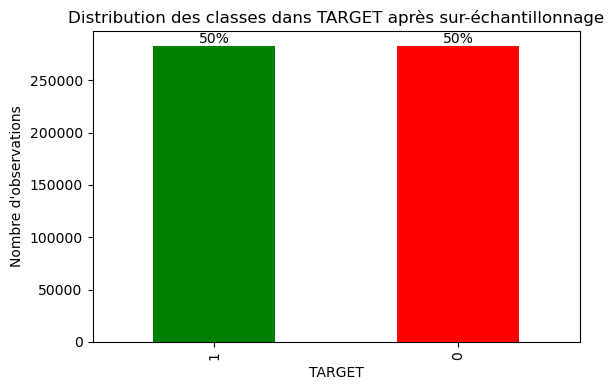

In [33]:
# Comptage des classes
counts = df_upsampled['TARGET'].value_counts()
percentages = counts / counts.sum() * 100

# Création du graphique
fig, ax = plt.subplots(figsize=(6,4))

counts.plot(kind='bar', ax=ax, color=['green', 'red'])

# Ajout des pourcentages sur les barres
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{percentages[i]:.0f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Distribution des classes dans TARGET après sur-échantillonnage')
ax.set_xlabel('TARGET')
ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

# Construction du Pipeline de Machine Learning

In [34]:
folder_path = r'C:\Users\NDEYE SEYNABOU TALL\Pratique_Mr_SY\Projet_credit_scoring'
for filename in os.listdir(folder_path):
    print (filename)

.ipynb_checkpoints
application.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
HomeCredit_columns_description.csv
installments_payments.csv
POS_CASH_balance.csv
previous_application.csv
sample_submission.csv


In [35]:
print(credit_train.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)


In [36]:
file_path = os.path.join(folder_path, 'application_train.csv')
credit_train = pd.read_csv(file_path)
credit_train.shape


(307511, 122)

In [37]:
# Divisez les données en X (caractéristiques) et y (cible)
X = credit_train.drop(columns=['TARGET'])  # Caractéristiques
y = credit_train['TARGET']                 # Variable cible

# Divisez les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer deux cadres de données différents pour les classes majoritaire et minoritaire
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train['TARGET'] == 0]  # Classe majoritaire (0)
df_minority = df_train[df_train['TARGET'] == 1]  # Classe minoritaire (1)

# Suréchantillonner la classe minoritaire dans l'ensemble d'entraînement
df_minority_upsampled = resample(df_minority, 
                                 replace=True,      # échantillonner avec remplacement
                                 n_samples=len(df_majority),  # Pour correspondre à la classe majoritaire
                                 random_state=42)   # Résultats reproductibles

# Combiner la classe majoritaire avec la classe minoritaire suréchantillonnée
df_train_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Séparer les caractéristiques (X) et la cible (y) après suréchantillonnage
X_train_upsampled = df_train_upsampled.drop(columns=['TARGET'])
y_train_upsampled = df_train_upsampled['TARGET']

# Afficher les tailles des classes avant et après suréchantillonnage
print(f"Taille de la classe majoritaire avant suréchantillonnage : {len(df_majority)}")
print(f"Taille de la classe minoritaire avant suréchantillonnage : {len(df_minority)}")
print(f"Taille de l'ensemble d'entraînement après suréchantillonnage : {len(df_train_upsampled)}")

# Vérifier la distribution des classes après suréchantillonnage
print(f"Répartition des classes après suréchantillonnage dans l'ensemble d'entraînement :")
print(df_train_upsampled['TARGET'].value_counts())

Taille de la classe majoritaire avant suréchantillonnage : 226132
Taille de la classe minoritaire avant suréchantillonnage : 19876
Taille de l'ensemble d'entraînement après suréchantillonnage : 452264
Répartition des classes après suréchantillonnage dans l'ensemble d'entraînement :
TARGET
0    226132
1    226132
Name: count, dtype: int64


In [38]:
import os
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Définir le chemin du dossier
folder_path = r'C:\Users\NDEYE SEYNABOU TALL\Pratique_Mr_SY\Projet_credit_scoring'

# Charger les fichiers train et test
credit_train = pd.read_csv(os.path.join(folder_path, 'application_train.csv'))
credit_test = pd.read_csv(os.path.join(folder_path, 'application_test.csv'))

# Identifier les colonnes numériques et catégoriques
numeric_columns = credit_train.select_dtypes(include=['float64', 'int64']).columns.drop('TARGET')
categorical_columns = credit_train.select_dtypes(include=['object']).columns

# Créer un préprocesseur pour les colonnes numériques et catégoriques
preprocessor = ColumnTransformer(transformers=[('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                                                                 ('scaler', StandardScaler())]), numeric_columns),
                                               ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                                                 ('encoder', OneHotEncoder(handle_unknown='ignore'))
                                                                ]), categorical_columns)])

# Créer un pipeline complet avec un modèle
pipeline = Pipeline([('preprocessor', preprocessor),('classifier', RandomForestClassifier(random_state=42))])  # Exemple de modèle



# Séparer X et y pour le train
#X_train = credit_train.drop('TARGET', axis=1)
#y_train = credit_train['TARGET']

# Créer X_test sans TARGET, car TARGET n'est pas disponible pour le test
X_test = credit_test.drop('TARGET', axis=1, errors='ignore')  # 'errors' pour éviter une erreur si 'TARGET' n'existe pas

# Entraîner le pipeline
pipeline.fit(X_train_upsampled, y_train_upsampled)

# Prédire sur le jeu de test (sans TARGET)
y_pred = pipeline.predict(X_test)

# Si vous avez besoin d'évaluer le modèle, vous devez avoir les véritables valeurs de 'TARGET' dans un autre jeu de données
# Si vous n'avez pas de 'TARGET' dans le jeu de test, vous pouvez juste prédire et utiliser ces prédictions pour les résultats futurs.
print("Prédictions sur le jeu de test :")
print(y_pred)

Prédictions sur le jeu de test :
[0 0 0 ... 0 0 0]


#### On remarque que le jeu de test prédit en premier lieu la classe 0

In [39]:
# Divisez les données en X (caractéristiques) et y (cible)
X = credit_train.drop(columns=['TARGET'])  # Caractéristiques
y = credit_train['TARGET']                 # Variable cible

# Divisez les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer deux cadres de données différents pour les classes majoritaire et minoritaire
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train['TARGET'] == 0]  # Classe majoritaire (0)
df_minority = df_train[df_train['TARGET'] == 1]  # Classe minoritaire (1)

# Suréchantillonner la classe minoritaire dans l'ensemble d'entraînement
df_minority_upsampled = resample(df_minority, 
                                 replace=True,      # échantillonner avec remplacement
                                 n_samples=len(df_majority),  # Pour correspondre à la classe majoritaire
                                 random_state=42)   # Résultats reproductibles

# Combiner la classe majoritaire avec la classe minoritaire suréchantillonnée
df_train_upsampled = pd.concat([df_majority, df_minority_upsampled])
print(df_train_upsampled['TARGET'].value_counts())

TARGET
0    226132
1    226132
Name: count, dtype: int64


In [40]:
# Définir la grille d'hyperparamètres
from sklearn.model_selection import GridSearchCV
param_grid = {'classifier__n_estimators': [50],
              'classifier__max_depth': [None,10],
              'classifier__min_samples_split': [5]}
    
# Configurer la recherche par grille
grid_search = GridSearchCV(pipeline, param_grid, cv= 3, scoring='precision', n_jobs=-1)

# Effectuer la recherche
grid_search.fit(X_train_upsampled, y_train_upsampled)

# Meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}


# Modèle de classification : Testez plusieurs modèles pour la prédiction du risque de défaut :

### Régression Logistique : Modèle de référence souvent utilisé en économétrie financière

In [41]:
# Pipeline pour la régression logistique
logistic_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', LogisticRegression(max_iter=2000))])

# Entraîner et évaluer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_pipeline.fit(X_train_upsampled, y_train_upsampled)
logistic_predictions = logistic_pipeline.predict(X_test)
logistic_auc = roc_auc_score(y_test, logistic_pipeline.predict_proba(X_test)[:, 1])

print(f"Régression Logistique - AUC: {logistic_auc:.2f}")
print(classification_report(y_test, logistic_predictions))

Régression Logistique - AUC: 0.75
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56554
           1       0.16      0.68      0.26      4949

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



## Random Forest

In [42]:
# Pipeline pour Random Forest
random_forest_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                         ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

random_forest_pipeline.fit(X_train_upsampled, y_train_upsampled)
rf_predictions = random_forest_pipeline.predict(X_test)
rf_auc = roc_auc_score(y_test, random_forest_pipeline.predict_proba(X_test)[:, 1])

print(f"Random Forest - AUC: {rf_auc:.2f}")
print(classification_report(y_test, rf_predictions))

Random Forest - AUC: 0.73
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.44      0.01      0.02      4949

    accuracy                           0.92     61503
   macro avg       0.68      0.51      0.49     61503
weighted avg       0.88      0.92      0.88     61503



## Gradient Boosting

In [43]:

# Pipeline pour Gradient Boosting
gb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))])

gb_pipeline.fit(X_train_upsampled, y_train_upsampled)
gb_predictions = gb_pipeline.predict(X_test) 
gb_auc = roc_auc_score(y_test, gb_pipeline.predict_proba(X_test)[:, 1])

print(f"Gradient Boosting - AUC: {gb_auc:.2f}")
print(classification_report(y_test, gb_predictions))

Gradient Boosting - AUC: 0.75
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56554
           1       0.16      0.68      0.26      4949

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



## Validation croisée et optimisation des hyperparamètres

In [44]:
# Résumé des résultats
models_auc = {'Régression Logistique': logistic_auc,
              'Random Forest': rf_auc,
              'Gradient Boosting': gb_auc}

print("\nRésumé des performances (AUC) :")
for model, auc in models_auc.items():
    print(f"{model}: {auc:.2f}")


Résumé des performances (AUC) :
Régression Logistique: 0.75
Random Forest: 0.73
Gradient Boosting: 0.75


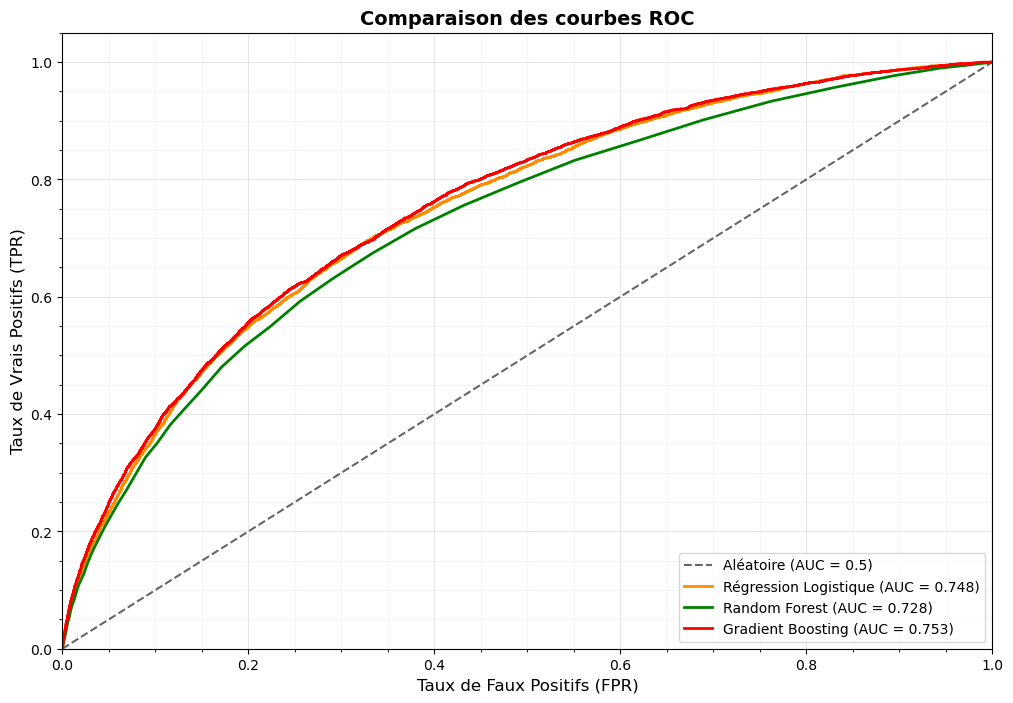

In [53]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(X_test, y_test, models_dict, figsize=(12, 8)):
    """
    Trace les courbes ROC pour plusieurs modèles.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionnaire {'nom_modele': modele_entraine}
    """
    plt.figure(figsize=figsize)
    
    # Ligne de référence (aléatoire)
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', alpha=0.6)
    
    colors = ['darkorange', 'green', 'red', 'purple', 'brown']
    
    for (name, model), color in zip(models_dict.items(), colors):
        # Prédictions probabilistes
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            # Pour les modèles sans predict_proba (utiliser decision_function)
            y_pred_proba = model.decision_function(X_test)
            y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (y_pred_proba.max() - y_pred_proba.min())
        
        # Calcul courbe ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        # Tracer
        plt.plot(fpr, tpr, color=color, lw=2, 
                 label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Personnalisation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    plt.title('Comparaison des courbes ROC', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # Ajouter une grille plus fine
    plt.minorticks_on()
    plt.grid(which='minor', alpha=0.1)
    
    plt.show()

# Exemple d'utilisation si vous avez plusieurs modèles
models_to_compare = {
    'Régression Logistique': logistic_pipeline,
    'Random Forest':random_forest_pipeline,  # à décommenter si disponible
    'Gradient Boosting': gb_pipeline  # à décommenter si disponible
}

plot_roc_curves(X_test, y_test, models_to_compare)

In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curves(X_test, y_test, models_dict, figsize=(12, 8),
                    save_path="courbes_ROC_modeles.png"):
    """
    Trace les courbes ROC pour plusieurs modèles et les sauvegarde en PNG.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionnaire {'nom_modele': modele_entraine}
    save_path : str
        Chemin du fichier PNG à sauvegarder
    """
    plt.figure(figsize=figsize)
    
    # Ligne de référence (aléatoire)
    plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', alpha=0.6)
    
    colors = ['darkorange', 'green', 'red', 'purple', 'brown']
    
    for (name, model), color in zip(models_dict.items(), colors):
        # Prédictions probabilistes
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test)
            y_pred_proba = (y_pred_proba - y_pred_proba.min()) / (
                y_pred_proba.max() - y_pred_proba.min()
            )
        
        # Courbe ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(
            fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})'
        )
    
    # Personnalisation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    plt.title('Comparaison des courbes ROC', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.minorticks_on()
    plt.grid(which='minor', alpha=0.1)
    
    # SAUVEGARDE PNG (IMPORTANT)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


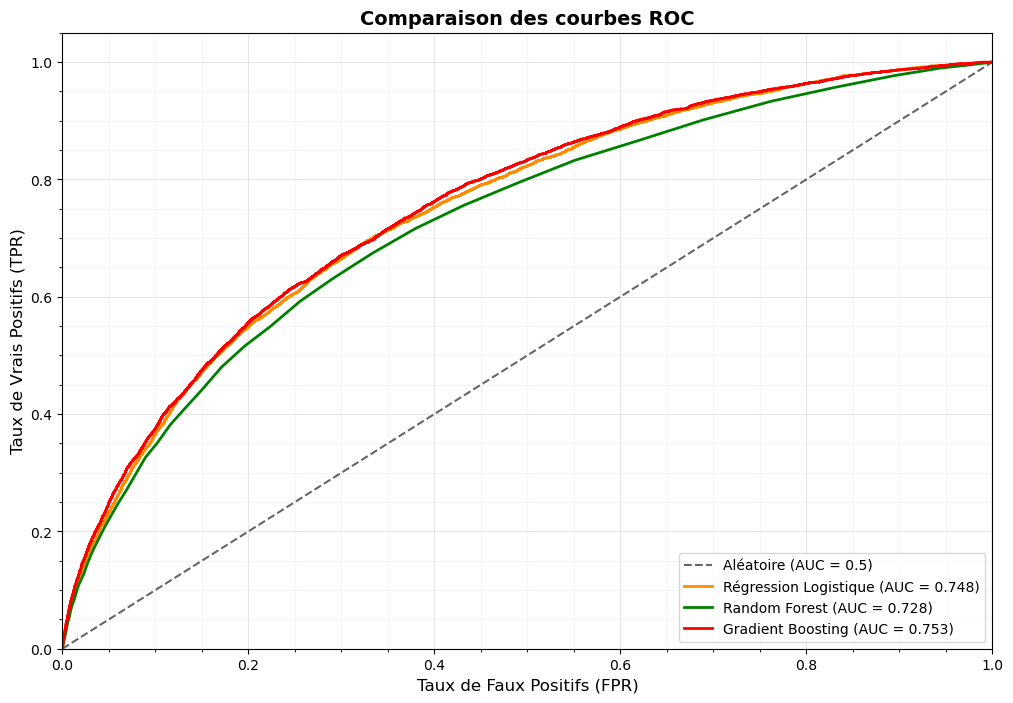

In [55]:
models_to_compare = {
    'Régression Logistique': logistic_pipeline,
    'Random Forest': random_forest_pipeline,
    'Gradient Boosting': gb_pipeline
}

plot_roc_curves(
    X_test,
    y_test,
    models_to_compare,
    save_path="courbes_ROC_credit_scoring.png"
)

## Recherche  aléatoire (Random Search) pour optimiser les hyperparamètres


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Identifier les colonnes numériques et catégoriques
numeric_columns = credit_train.select_dtypes(include=['float64', 'int64']).columns.drop('TARGET')
categorical_columns = credit_train.select_dtypes(include=['object']).columns

# Créer un préprocesseur pour les colonnes numériques et catégoriques
preprocessor = ColumnTransformer(transformers=[('num', Pipeline([('imputer', SimpleImputer(strategy='mean')),
                                                                 ('scaler', StandardScaler())]), numeric_columns),
                                               ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                                                 ('encoder', OneHotEncoder(handle_unknown='ignore'))
                                                                ]), categorical_columns)])



# Définir le modèle de base
rf_model = RandomForestClassifier(random_state=42)

# Créer un pipeline avec le préprocesseur et le modèle
pipeline = Pipeline([('preprocessor', preprocessor),('classifier', rf_model)])

# Définir la grille de recherche des hyperparamètres
param_distributions = {'classifier__n_estimators': [50, 100],       # Réduction à 2 valeurs pour le nombre d'arbres
                       'classifier__max_depth': [None, 10],         # Réduction à 2 valeurs pour la profondeur maximale
                       'classifier__min_samples_split': [2, 5],     # Réduction à 2 valeurs pour la division des nœuds
                       'classifier__min_samples_leaf': [1, 2],      # Réduction à 2 valeurs pour le nombre d'échantillons par feuille
                       'classifier__bootstrap': [True] }             # Fixer une seule valeur pour bootstrap

# Configurer RandomizedSearchCV
#random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_distributions,
#                                   n_iter=5,scoring='roc_auc', cv=3, verbose=2, random_state=42, n_jobs=-1)            
  
# Configurer RandomizedSearchCV avec le pipeline
random_search = RandomizedSearchCV(estimator=pipeline,param_distributions=param_distributions, n_iter=5,scoring='roc_auc',cv=3,
                                   verbose=2,random_state=42,n_jobs=-1)    
                                                      
# Entraîner RandomizedSearchCV
random_search.fit(X_train_upsampled, y_train_upsampled)

# Afficher les meilleurs paramètres et le score correspondant
print("Meilleurs hyperparamètres : ", random_search.best_params_)
print(f"Meilleur score AUC : {random_search.best_score_:.2f}")

# Évaluer le modèle avec les meilleurs paramètres sur les données de test
best_model = random_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC sur les données de test : {auc_score:.2f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


####   Plus rapide que Grid Search, surtout si la grille contient un grand nombre de combinaisons

# Évaluation des Modèles et Interprétation

### Utilisez des métriques comme l’AUC-ROC, le F1-score, et la précision pour évaluer et comparer la performance de chaque modèle

In [129]:
# Nombre de classes dans l'ensemble d'entraînement
#print("Distribution des classes dans l'ensemble d'entraînement :")
#print(y_train.value_counts())
#print()

Distribution des classes dans l'ensemble d'entraînement :
0    226132
1     19876
Name: TARGET, dtype: int64



In [130]:
# Nombre de classes dans l'ensemble de test
#print("Distribution des classes dans l'ensemble de test :")
#print(y_test.value_counts())

Distribution des classes dans l'ensemble de test :
0    56554
1     4949
Name: TARGET, dtype: int64


In [59]:
# Diviser les données en X et y
X = credit_train.drop(columns=['TARGET'])  # Caractéristiques
y = credit_train['TARGET']                 # Variable cible

# Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer deux cadres de données différents pour les classes majoritaire et minoritaire
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train['TARGET'] == 0]  # Classe majoritaire (0)
df_minority = df_train[df_train['TARGET'] == 1]  # Classe minoritaire (1)

# Suréchantillonner la classe minoritaire dans l'ensemble d'entraînement
df_minority_upsampled = resample(df_minority, 
                                 replace=True,      # échantillonner avec remplacement
                                 n_samples=len(df_majority),  # Pour correspondre à la classe majoritaire
                                 random_state=42)   # Résultats reproductibles

# Combiner la classe majoritaire avec la classe minoritaire suréchantillonnée
df_train_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Séparer les caractéristiques (X) et la cible (y) après suréchantillonnage
X_train_upsampled = df_train_upsampled.drop(columns=['TARGET'])
y_train_upsampled = df_train_upsampled['TARGET']


# Identifier les colonnes numériques et catégoriques
numeric_columns = X_train_upsampled.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = X_train_upsampled.select_dtypes(include=['object']).columns

# Créer un préprocesseur pour les colonnes numériques et catégoriques
preprocessor = ColumnTransformer(transformers=[('num', Pipeline([('imputer', SimpleImputer(strategy='mean')), 
                                                                ('scaler', StandardScaler())]), numeric_columns),
                                               ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')) ,
                                                                 ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_columns)])

# Définir le modèle de base
rf_model = RandomForestClassifier(random_state=42)

# Créer un pipeline
pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', rf_model)])

# Entraîner le modèle avec l'ensemble d'entraînement suréchantillonné
pipeline.fit(X_train_upsampled, y_train_upsampled)

# Prédire sur l'ensemble de test
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilité pour AUC-ROC

# Calculer les métriques
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Afficher les résultats
print(f"AUC-ROC: {auc_score:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"Précision: {precision:.2f}")

AUC-ROC: 0.73
F1-score: 0.02
Précision: 0.44


## Ajustement du seuil permet d'optimiser les performances du modèle 

In [63]:
# Prédire les probabilités de la classe positive (classe 1)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Définir un seuil personnalisé (par exemple, 0.2)
threshold = 0.2

# Appliquer ce seuil pour prédire les classes
y_pred_custom_threshold = (y_pred_proba > threshold).astype(int)

# Calculer les métriques avec ce seuil ajusté
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred_custom_threshold)
precision = precision_score(y_test, y_pred_custom_threshold)
accuracy = accuracy_score(y_test, y_pred_custom_threshold)

# Afficher les résultats
print(f"AUC-ROC: {auc_score:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"Précision: {precision:.2f}")
print(f"Précision globale : {accuracy:.2f}")

AUC-ROC: 0.73
F1-score: 0.28
Précision: 0.22
Précision globale : 0.84


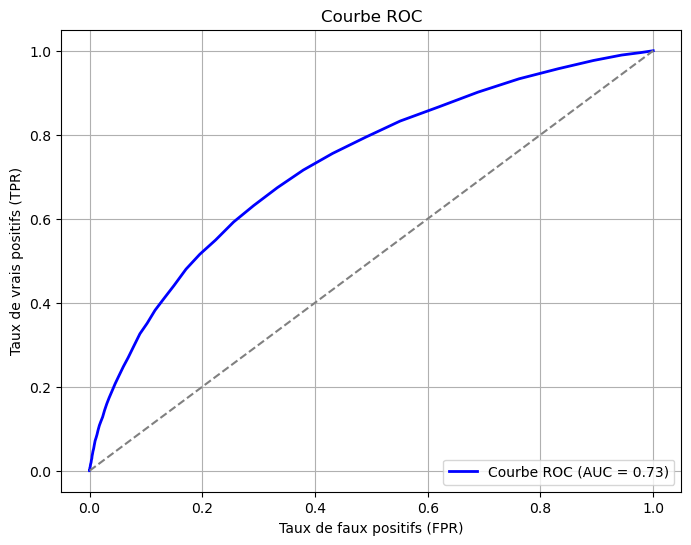

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Prédire les probabilités de la classe positive (classe 1)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculer les taux de vrais positifs (TPR) et faux positifs (FPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculer l'AUC (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')

# Ajouter la ligne diagonale (random classifier)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Ajouter des labels et un titre
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')

# Afficher le graphique
plt.grid(True)
plt.show()